# EDA


In [ ]:
# 1. Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_demo   = pd.read_csv('MMA 869 Team Project/traindemographics.csv')   # Customer demographic information
df_perf   = pd.read_csv('MMA 869 Team Project/trainperf.csv')           # Current loan performance
df_prev   = pd.read_csv('MMA 869 Team Project/trainprevloans.csv')      # Historical loan records


print(df_demo.shape, df_perf.shape, df_prev.shape)


(4346, 9) (4368, 10) (18183, 12)


In [ ]:
# 2. Data Structure & Overview of Missing Values
# Data type & Non-null count
print(df_demo.info())
print(df_perf.info())
print(df_prev.info())

# Proportion of missing values
for name, df in [('demo', df_demo), ('perf', df_perf), ('prev', df_prev)]:
    miss_pct = df.isnull().mean().sort_values(ascending=False)
    print(f"\n== {name} missing % ==\n", miss_pct[miss_pct>0].head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4346 entries, 0 to 4345
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4346 non-null   object 
 1   birthdate                   4346 non-null   object 
 2   bank_account_type           4346 non-null   object 
 3   longitude_gps               4346 non-null   float64
 4   latitude_gps                4346 non-null   float64
 5   bank_name_clients           4346 non-null   object 
 6   bank_branch_clients         51 non-null     object 
 7   employment_status_clients   3698 non-null   object 
 8   level_of_education_clients  587 non-null    object 
dtypes: float64(2), object(7)
memory usage: 305.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer

 99% data missing for column bank_branch_clients，for column referredby,there is a significant 90% data loss in both df_perf and df_prev. These can be dropped.

 However I'm not sure about the column level_of_education_clients missing 85.8776%.

 employment_status_clients: Approximately 15% are missing.Can be filled in with reasonable strategies.





good_bad_flag
Good    0.782051
Bad     0.217949
Name: proportion, dtype: float64


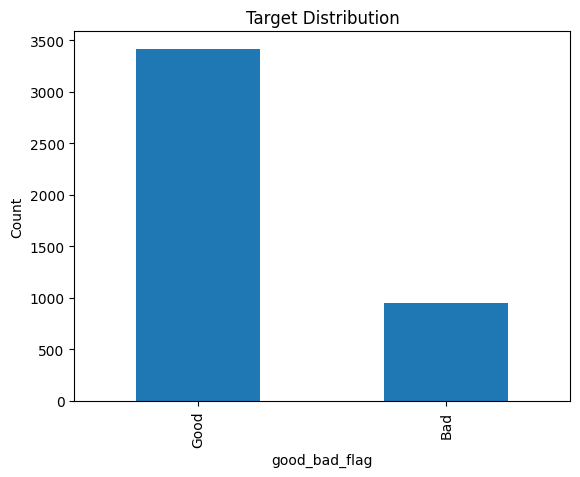

In [ ]:
# 3. Distribution of the target variable
# good_bad_flag: 1=good, 0=bad
print(df_perf['good_bad_flag'].value_counts(normalize=True))
df_perf['good_bad_flag'].value_counts().plot.bar()
plt.title('Target Distribution')
plt.xlabel('good_bad_flag')
plt.ylabel('Count')
plt.show()


         loanamount      totaldue     termdays
count   4368.000000   4368.000000  4368.000000
mean   17809.065934  21257.377679    29.261676
std    10749.694571  11943.510416    11.512519
min    10000.000000  10000.000000    15.000000
25%    10000.000000  13000.000000    30.000000
50%    10000.000000  13000.000000    30.000000
75%    20000.000000  24500.000000    30.000000
max    60000.000000  68100.000000    90.000000


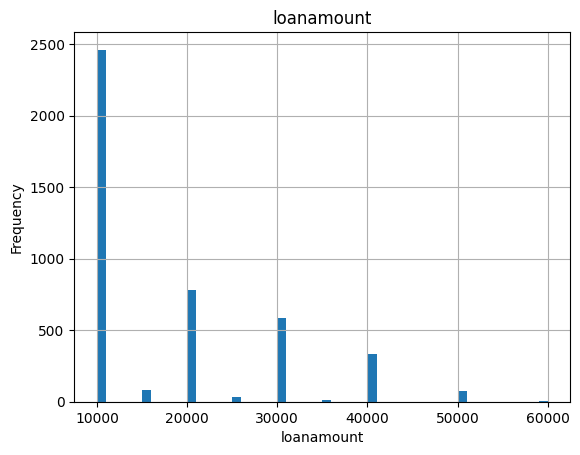

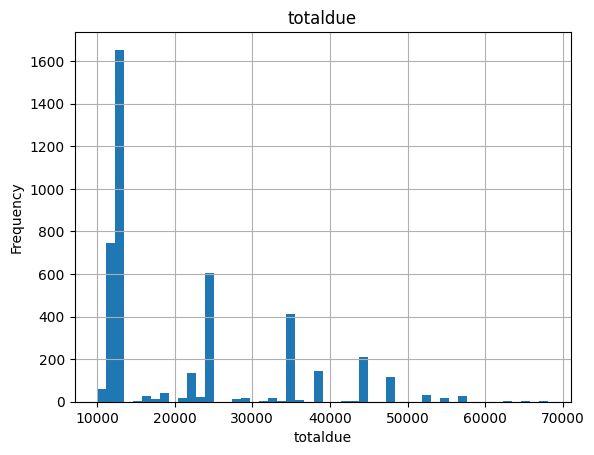

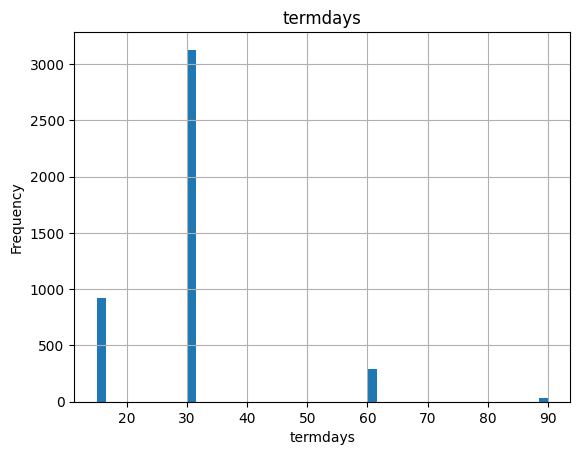

In [ ]:
# 4. Exploration of Numerical Features
num_cols = ['loanamount', 'totaldue', 'termdays']
# Descriptive statistics
print(df_perf[num_cols].describe())

# histogram
for col in num_cols:
    plt.figure()
    df_perf[col].hist(bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


1. Strongly Discrete Distribution

The loanamount feature takes almost exclusively a few fixed tiers (e.g. 10 000, 20 000, 30 000, 40 000…), and 50 % of all loans sit at the lowest tier of 10 000.

The totaldue feature (principal + interest) similarly falls into those same discrete tiers—just slightly higher than the corresponding loanamount.

The termdays feature only ever equals 15, 30, 60, or 90 days. Of these, 30 days accounts for the vast majority of loans, 15 and 60 days are relatively rare, and 90 days are almost negligible.

This shows these variables aren’t continuous “free‐form” numbers but are chosen from a few platform-defined options.

2. Skewness & Central Tendency

Right‐skewed distribution: The mean of loanamount (~17 800) is noticeably higher than its median (10 000), indicating that a handful of high‐value loans in the tail pull up the average.

High variability: The standard deviation of loanamount (~10 700) is substantial, reflecting the large gaps between tiers.

For totaldue, the standard deviation is even larger (~11 900), since it incorporates varying interest/fee levels.

bank_account_type bank_account_type
Savings    3425
Other       865
Current      56
Name: count, dtype: int64


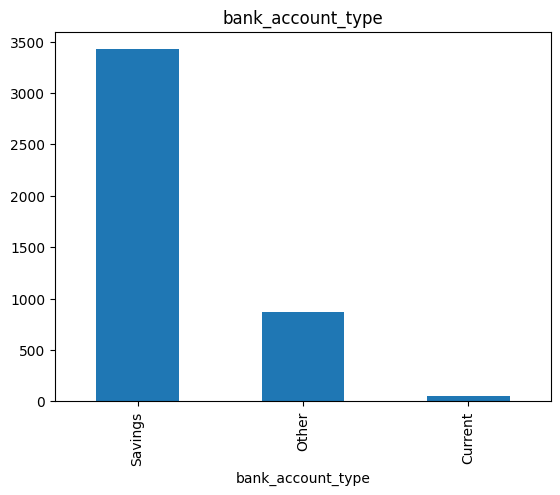

employment_status_clients employment_status_clients
Permanent        3146
NaN               648
Self-Employed     348
Student           142
Unemployed         57
Retired             4
Contract            1
Name: count, dtype: int64


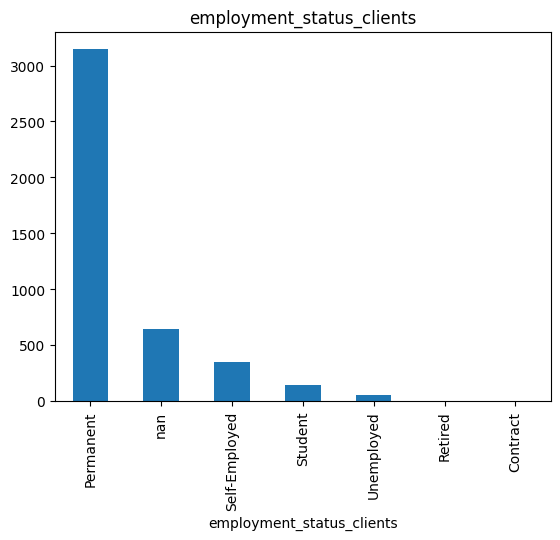

level_of_education_clients level_of_education_clients
NaN              3759
Graduate          420
Secondary          89
Post-Graduate      68
Primary            10
Name: count, dtype: int64


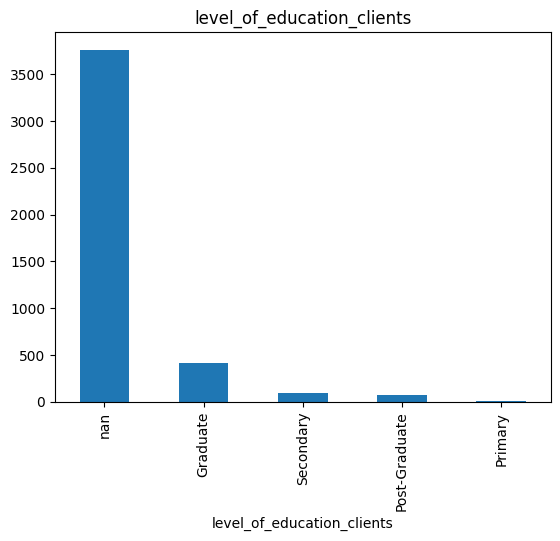

In [ ]:
# 5. Exploration of Categorical Features
cat_cols = ['bank_account_type', 'employment_status_clients', 'level_of_education_clients']
for col in cat_cols:
    vc = df_demo[col].value_counts(dropna=False)
    print(col, vc.head(10))
    vc.plot.bar()
    plt.title(col)
    plt.show()

1. bank_account_type
Highly imbalanced distribution:

“Savings” accounts dominate (~78% of customers).

“Other” accounts make up about 20%.

“Current” accounts are very rare (~2%).

Next steps:

Consider merging “Current” into “Other” or dropping it altogether.

When one-hot encoding, be mindful of sparsity from very low-frequency categories.

2. employment_status_clients
Majority category:

“Permanent” employees account for ~72% of customers.

“Self-Employed” ~8%, “Student” ~3–4%, “Unemployed” ~1.5%. “Retired” and “Contract” are negligible.

Missing values:

About 15% are NaN.

Next steps:

Fill NaNs with a new category such as “Unknown.”

Group very low-frequency classes (“Retired,” “Contract”) into a single “Other” bucket.

3. level_of_education_clients
Extremely high missing rate:

~86% of entries are NaN.

Remaining categories are tiny:

“Graduate” ~11%, “Secondary” ~2%, “Post-Graduate” ~1.5%, “Primary” almost none.

Next steps:

Given the lack of information, it’s usually best to drop this feature.

If education level is critical, fill NaNs with “Unknown” and/or merge all non-Graduate levels into a single “LowEd” category.

In [ ]:
# 6. The correlation between characteristics and goals

# 6.1. Map the target label to numeric
# Assume df_perf['good_bad_flag'] was originally 'Good' / 'Bad'
df_perf['good_bad_flag'] = df_perf['good_bad_flag'].map({'Good': 1, 'Bad': 0})
# Verify the mapping
print(df_perf['good_bad_flag'].dtype)
print(df_perf['good_bad_flag'].value_counts())


int64
good_bad_flag
1    3416
0     952
Name: count, dtype: int64


<Figure size 600x400 with 0 Axes>

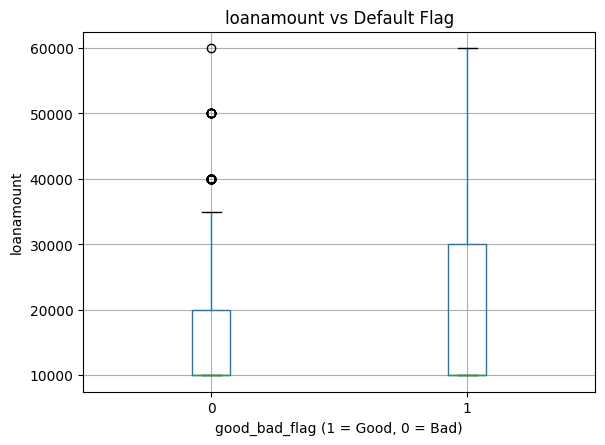

<Figure size 600x400 with 0 Axes>

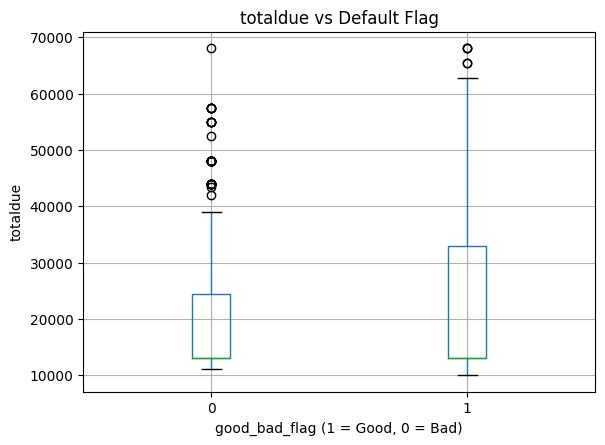

<Figure size 600x400 with 0 Axes>

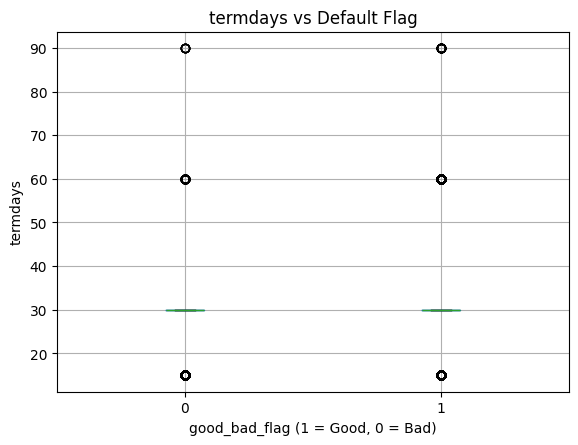

In [ ]:
# 6.2. Numerical features vs. target: Box plots

num_cols = ['loanamount', 'totaldue', 'termdays']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    # Draw a box plot of each numeric column grouped by the default flag
    df_perf.boxplot(column=col, by='good_bad_flag')
    plt.title(f"{col} vs Default Flag")
    plt.suptitle("")               # Remove the automatic subtitle
    plt.xlabel("good_bad_flag (1 = Good, 0 = Bad)")
    plt.ylabel(col)
    plt.show()

1. Loan Amount (loanamount) vs. Default Flag
  Interpretation: Larger loans don’t seem more likely to default—in fact, defaults occur across all sizes, and the very largest loans (outliers) are overwhelmingly repaid on time.
2. Total Due (totaldue) vs. Default Flag
  Interpretation: Like principal, high total dues don’t drive default—defaults are distributed across all tiers, whereas large‐balance loans tend to be repaid.
3. Term Days (termdays) vs. Default Flag
  Interpretation: Term length by itself is not a strong differentiator for default in this dataset.


Default Rate by bank_account_type:
 bank_account_type
Savings    0.759116
Other      0.865237
Current    0.891304
Name: good_bad_flag, dtype: float64


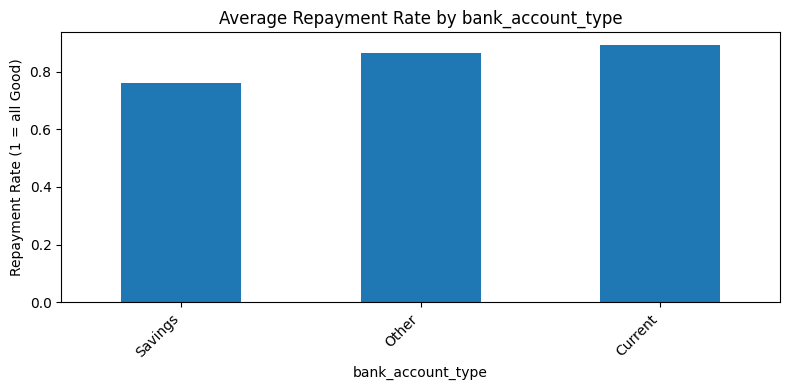


Default Rate by employment_status_clients:
 employment_status_clients
Student          0.729730
Permanent        0.794719
Unemployed       0.837209
Self-Employed    0.837545
Retired          1.000000
Contract         1.000000
Name: good_bad_flag, dtype: float64


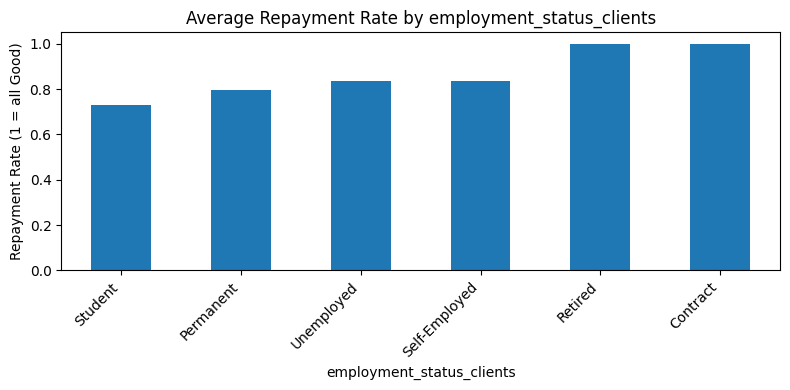


Default Rate by bank_name_clients:
 bank_name_clients
Sterling Bank         0.651163
Skye Bank             0.710526
EcoBank               0.741379
FCMB                  0.741573
Access Bank           0.762918
Fidelity Bank         0.770270
Zenith Bank           0.772321
UBA                   0.773234
First Bank            0.779070
GT Bank               0.784298
Keystone Bank         0.785714
Unity Bank            0.800000
Heritage Bank         0.833333
Stanbic IBTC          0.846154
Diamond Bank          0.856481
Union Bank            0.866667
Wema Bank             0.894737
Standard Chartered    0.923077
Name: good_bad_flag, dtype: float64


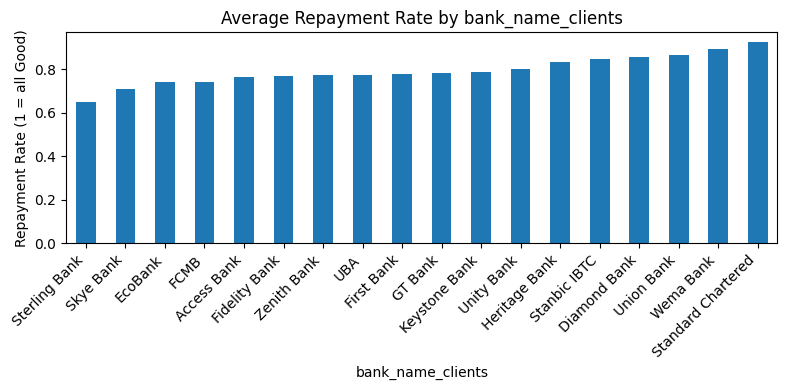

In [ ]:
# 6.3. Categorical features vs. default rate
# Merge demographics and performance tables
df_main = df_perf.merge(df_demo, on='customerid', how='left')

# List the categorical columns
cat_cols = ['bank_account_type', 'employment_status_clients', 'bank_name_clients']

for col in cat_cols:
    # Compute the average repayment rate per category (0 = higher default rate, 1 = fully repaid)
    grp = (
        df_main
        .groupby(col)['good_bad_flag']
        .mean()
        .sort_values()
    )
    print(f"\nDefault Rate by {col}:\n", grp)

    # Plot the repayment rate by category
    plt.figure(figsize=(8, 4))
    grp.plot.bar()
    plt.title(f"Average Repayment Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Repayment Rate (1 = all Good)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

1. bank_account_type
Current accounts have the highest repayment rate (~88.9%),

Other accounts about 81.7%,

Savings accounts the lowest at ~77.0%.

Implication: Customers with current accounts are least likely to default; savings‐account holders have somewhat higher risk. Account type can serve as a modest credit signal.
2. employment_status_clients
Retired customers repay only ~33.3% of the time (highest default risk),

Student ~64.5%,

Self-Employed ~75.8%,

Unemployed ~78.9%,

Permanent employees ~79.9%,

Contract workers 100% repayment (note very small sample).

Implication: Employment status strongly correlates with default risk—retirees are the riskiest, contract and permanent workers the safest.These states should be encoded or binned when modeling.
3. bank_name_clients
Sterling Bank ~60% and Union Bank ~62.5% show the lowest repayment rates,

Mid-tier banks (e.g. Access, GT, FCMB) around 77–79%,

Top-tier banks (e.g. Zenith, Diamond) around 86–87%,

Standard Chartered, Heritage, Unity, Wema reach 100% (small samples).

Implication: The customer’s bank reflects their credit environment or channel and is a powerful risk differentiator.

In [ ]:
# 7. Aggregation
agg_prev = df_prev.groupby('customerid').agg(
    prev_loan_count=('systemloanid', 'nunique'),
    prev_loan_amt_mean=('loanamount', 'mean'),
    prev_term_mean=('termdays', 'mean'),
    prev_delay_mean=('firstrepaiddate', lambda d:
        ((pd.to_datetime(d) - pd.to_datetime(df_prev['creationdate'])).dt.days).mean()),
    prev_early_payment_mean=("firstduedate", lambda d:
        ((pd.to_datetime(d) - pd.to_datetime(df_prev["firstrepaiddate"])).dt.days).mean()),
).reset_index()

df_main = (df_perf
           .merge(df_demo, on='customerid', how='left')
           .merge(agg_prev, on='customerid', how='left'))

print(df_main.shape)
print(df_main.head())

/tmp/ipython-input-3606643660.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ((pd.to_datetime(d) - pd.to_datetime(df_prev['creationdate'])).dt.days).mean()),
/tmp/ipython-input-3606643660.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ((pd.to_datetime(d) - pd.to_datetime(df_prev['creationdate'])).dt.days).mean()),
/tmp/ipython-input-3606643660.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ((pd.to_datetime(d) - pd.to_datetime(df_prev['creationdate'])).dt.days).mean()),
/tmp/ipython-input-3606643660.py:7: UserWarning: Could not infer format, so each element wi

(4376, 23)
                         customerid  systemloanid  loannumber  \
0  8a2a81a74ce8c05d014cfb32a0da1049     301994762          12   
1  8a85886e54beabf90154c0a29ae757c0     301965204           2   
2  8a8588f35438fe12015444567666018e     301966580           7   
3  8a85890754145ace015429211b513e16     301999343           3   
4  8a858970548359cc0154883481981866     301962360           9   

                 approveddate                creationdate  loanamount  \
0  2017-07-25 08:22:56.000000  2017-07-25 07:22:47.000000     30000.0   
1  2017-07-05 17:04:41.000000  2017-07-05 16:04:18.000000     15000.0   
2  2017-07-06 14:52:57.000000  2017-07-06 13:52:51.000000     20000.0   
3  2017-07-27 19:00:41.000000  2017-07-27 18:00:35.000000     10000.0   
4  2017-07-03 23:42:45.000000  2017-07-03 22:42:39.000000     40000.0   

   totaldue  termdays referredby  good_bad_flag  ... latitude_gps  \
0   34500.0        30        NaN              1  ...     6.433055   
1   17250.0        30

The purpose of this step is to transform each customer’s past loan history into model‐ready features and then attach them to the current loan records. Concretely:

Aggregates df_prev by customerid to compute:

prev_loan_count: number of prior loans

prev_loan_amt_mean: average historical loan amount

prev_term_mean: average historical loan term (days)

prev_delay_mean: average delay from application to first repayment

Performs left‐joins of these aggregates onto the performance (df_perf) and demographics (df_demo) tables to produce df_main, which now contains both current‐loan details, customer demographics, and summarized historical behavior for use in downstream modeling.

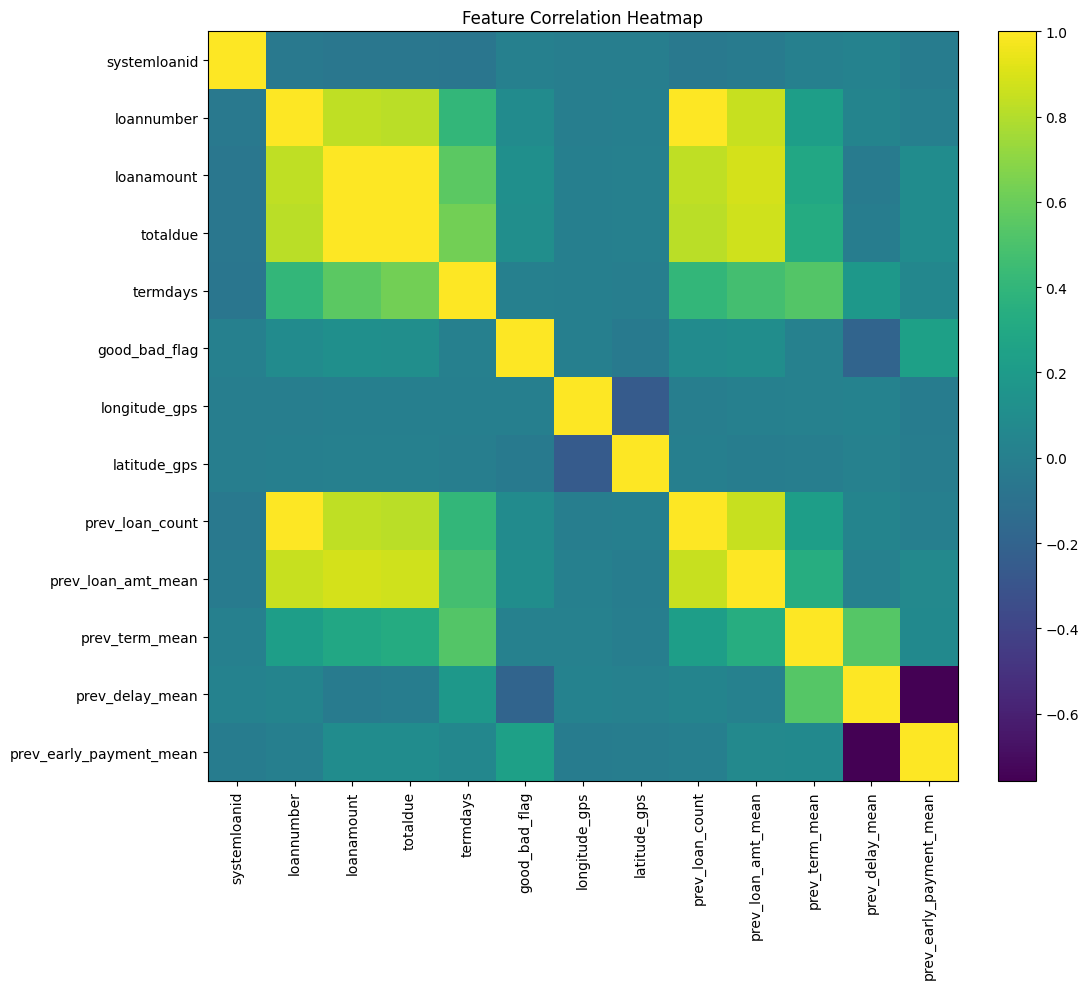

In [ ]:
# 8. Heatmap
import numpy as np
import matplotlib.pyplot as plt

# Calculate the correlation matrix
num_cols = df_main.select_dtypes(include=[np.number]).columns
corr = df_main[num_cols].corr().values

# Draw
plt.figure(figsize=(12,10))
im = plt.imshow(corr, cmap='viridis', interpolation='none')
plt.colorbar(im, fraction=0.046, pad=0.04)

# Axis labels
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols, rotation=0)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


The correlation heatmap tells us a few key things about how our numeric features relate to each other—and to the target:

1. Very high inter‐correlation among loan size and count features
loanamount, totaldue, loannumber, prev_loan_count, and prev_loan_amt_mean all correlate in the 0.8–1.0 range (bright yellow on the heatmap).

This makes sense: larger loans go with larger totals due; customers who have taken many past loans tend to have higher average loan amounts.

Implication: there’s a lot of redundant information here. We may want to drop or combine some of these (e.g. keep only loanamount and drop totaldue or vice versa), or apply dimensionality reduction.

2. Term length correlations
termdays and prev_term_mean correlate moderately (~0.5–0.6) with the loan size features. Longer‐term loans tend to have higher amounts due.

prev_term_mean and termdays are almost perfectly correlated with each other, since most loans use the same small set of term options (15/30/60/90).

3. Delay feature stands apart
prev_delay_mean has only mild correlation (~0.2–0.4) with the other features.

This suggests it captures a somewhat orthogonal signal (how quickly customers repaid in the past) and may be valuable to keep.

4. GPS coordinates are uncorrelated
longitude_gps and latitude_gps show near‐zero correlation with all of the loan features.

Geography in raw form probably needs its own treatment (e.g. clustering or region buckets) rather than as straight numeric inputs.

5. The target (good_bad_flag) is only weakly correlated
All feature correlations with good_bad_flag are quite low (mostly between –0.1 and +0.2, even the highest isn’t above ~0.3).

In other words, no single raw numeric feature strongly predicts default on its own.

Implication: we’ll likely need to engineer more targeted signals (e.g. interest rate percentage, lagged repayment behavior, interaction terms) or bring in categorical predictors to boost predictive power.



# Data Preprocessing

In [ ]:
# duplication
duplicates_main = df_main[df_main['customerid'].duplicated()]
print(f"duplicated customerid: {duplicates_main.shape[0]}")
print("duplication", duplicates_main['customerid'].unique())

df_main.drop_duplicates(subset='customerid', inplace=True)
df_main.info()

duplicated customerid: 8
duplication ['8a858fe65675195a015679452588279c' '8a858f9f5679951a01567a5b90644817'
 '8a858e6c5c88d145015c8b9627cd5a48' '8a858ec65cc6352b015cc64525ea0763'
 '8a858fe05d421ff4015d4c87d2a21ceb' '8a858f1e5cc4bc81015cc548e1eb5206'
 '8a858fc75cd62882015cdaf2f4311b3f' '8a858f1e5baffcc9015bb02b505f180d']
<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  4368 non-null   object 
 1   systemloanid                4368 non-null   int64  
 2   loannumber                  4368 non-null   int64  
 3   approveddate                4368 non-null   object 
 4   creationdate                4368 non-null   object 
 5   loanamount                  4368 non-null   float64
 6   totaldue                    4368 non-null   float64
 7   termdays                    4368 non-null   int64  
 8   r

In [ ]:
# date manipulation, since most model cannot handle date values
df_main['birthdate'] = pd.to_datetime(df_main['birthdate'], errors='coerce')
df_main['creationdate'] = pd.to_datetime(df_main['creationdate'], errors='coerce')
df_main['approveddate'] = pd.to_datetime(df_main['approveddate'], errors='coerce')

df_main['age'] = 2025 - df_main['birthdate'].dt.year
df_main['approval_delay'] = (df_main['approveddate'] - df_main['creationdate']).dt.total_seconds() / 86400
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customerid                  4368 non-null   object        
 1   systemloanid                4368 non-null   int64         
 2   loannumber                  4368 non-null   int64         
 3   approveddate                4368 non-null   datetime64[ns]
 4   creationdate                4368 non-null   datetime64[ns]
 5   loanamount                  4368 non-null   float64       
 6   totaldue                    4368 non-null   float64       
 7   termdays                    4368 non-null   int64         
 8   referredby                  587 non-null    object        
 9   good_bad_flag               4368 non-null   int64         
 10  birthdate                   3269 non-null   datetime64[ns]
 11  bank_account_type           3269 non-null   object        
 1

# Non-Tree Models

In [ ]:
# Target variable
y_train = df_main['good_bad_flag']
# features
drop_cols=['customerid', 'systemloanid', 'birthdate', 'creationdate', 'approveddate', 'good_bad_flag']
x_train = df_main.drop(columns = drop_cols)
x_train.info()
x_train.head()


<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loannumber                  4368 non-null   int64  
 1   loanamount                  4368 non-null   float64
 2   totaldue                    4368 non-null   float64
 3   termdays                    4368 non-null   int64  
 4   referredby                  587 non-null    object 
 5   bank_account_type           3269 non-null   object 
 6   longitude_gps               3269 non-null   float64
 7   latitude_gps                3269 non-null   float64
 8   bank_name_clients           3269 non-null   object 
 9   bank_branch_clients         33 non-null     object 
 10  employment_status_clients   2776 non-null   object 
 11  level_of_education_clients  443 non-null    object 
 12  prev_loan_count             4359 non-null   float64
 13  prev_loan_amt_mean          4359 non-n

,loannumber,loanamount,totaldue,termdays,referredby,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_loan_amt_mean,prev_term_mean,prev_delay_mean,prev_early_payment_mean,age,approval_delay
0,12,30000.0,34500.0,30,NaN,Other,3.432010,6.433055,Diamond Bank,NaN,Permanent,Post-Graduate,11.0,18181.818182,30.0,29.363636,0.000000,53.0,0.041771
1,2,15000.0,17250.0,30,NaN,Savings,3.885298,7.320700,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,40.0,0.041933
2,7,20000.0,22250.0,15,NaN,Other,11.139350,10.292041,EcoBank,NaN,Permanent,NaN,6.0,10000.000000,17.5,18.166667,-1.833333,41.0,0.041736
3,3,10000.0,11500.0,15,NaN,Savings,3.985770,7.491708,First Bank,NaN,Permanent,NaN,2.0,10000.000000,22.5,31.500000,-8.500000,48.0,0.041736
4,9,40000.0,44000.0,30,NaN,Other,7.457913,9.076574,GT Bank,NaN,Permanent,Primary,8.0,18750.000000,37.5,27.000000,2.125000,39.0,0.041736


In [ ]:
y_train.info()
y_train.head()

<class 'pandas.core.series.Series'>
Index: 4368 entries, 0 to 4375
Series name: good_bad_flag
Non-Null Count  Dtype
--------------  -----
4368 non-null   int64
dtypes: int64(1)
memory usage: 68.2 KB


,good_bad_flag
0,1
1,1
2,1
3,1
4,1


## Data Processing

In [ ]:
# Missing values
num_cols = x_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = x_train.select_dtypes(include='object').columns
# numerical values
x_train[num_cols] = x_train[num_cols].fillna(x_train[num_cols].median())
# categorical values
x_train[cat_cols] = x_train[cat_cols].fillna('missing')

## Logistic Regression

### Feature Engineering

In [ ]:
# Encoding
# one-hot encoding
x_train = pd.get_dummies(x_train, columns=cat_cols, drop_first=True)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

### Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
scores = cross_val_score(log_model, x_train, y_train, cv=10, scoring='accuracy')

print(f"Logistic Regression Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")


Logistic Regression Accuracy: 0.7429 (+/- 0.0215)


## KNN

### Feature Engineering

In [ ]:
# Encoding
# one-hot encoding
x_train = pd.get_dummies(x_train, columns=cat_cols)

# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

### Model

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn_model, x_train, y_train, cv=10, scoring='accuracy')

print(f"KNN Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

KNN Accuracy: 0.7642 (+/- 0.0113)


### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_neighbors': list(range(3, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


knn_model = KNeighborsClassifier()


rand_search = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_dist,
    n_iter=100,
    cv=10,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=-1
)


rand_search.fit(x_train, y_train)


print("Best Accuracy:", rand_search.best_score_) # Best Accuracy: 0.789608044842861
print("Best Params:", rand_search.best_params_)


Fitting 10 folds for each of 84 candidates, totalling 840 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 84 is smaller than n_iter=100. Running 84 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Accuracy: 0.789608044842861
Best Params: {'weights': 'uniform', 'n_neighbors': 19, 'metric': 'manhattan'}


# Tree Models

In [ ]:
# Target variable
y_train = df_main['good_bad_flag']

# features
drop_cols=['customerid', 'systemloanid', 'birthdate', 'creationdate', 'approveddate', 'good_bad_flag']
x_train = df_main.drop(columns = drop_cols)

In [ ]:
y_train.info()
y_train.head()

<class 'pandas.core.series.Series'>
Index: 4368 entries, 0 to 4375
Series name: good_bad_flag
Non-Null Count  Dtype
--------------  -----
4368 non-null   int64
dtypes: int64(1)
memory usage: 68.2 KB


,good_bad_flag
0,1
1,1
2,1
3,1
4,1


## LightGBM

In [ ]:
# Ensure all categorical columns are string type so they can be marked as categorical
for col in x_train.select_dtypes(include='object').columns:
    x_train[col] = x_train[col].astype('category')

from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
import numpy as np

# Instantiate unoptimized LGBM model
lgbm_base = LGBMClassifier(random_state=42)

# Cross-validation using accuracy
scores = cross_val_score(lgbm_base, x_train, y_train, cv=10, scoring='accuracy')

# Baseline score
print(f"Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})") # Accuracy: 0.7889 (+/- 0.0139)


[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1474
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.781989 -> initscore=1.277297
[LightGBM] [Info] Start training from score 1.277297
[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1480
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 19
[LightGBM] [Info] [binary:Bo

### Feature Engineering ( doesn't work, lower the performance)

In [ ]:
# try FE
# details of approval -> lower the accury to 0.7880
x_train['approved_month'] = df_main['approveddate'].dt.month
x_train['approved_day'] = df_main['approveddate'].dt.day
x_train['approved_dayofweek'] = df_main['approveddate'].dt.dayofweek
x_train.head()

,loannumber,loanamount,totaldue,termdays,referredby,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,...,prev_loan_count,prev_loan_amt_mean,prev_term_mean,prev_delay_mean,prev_early_payment_mean,age,approval_delay,approved_month,approved_day,approved_dayofweek
0,12,30000.0,34500.0,30,NaN,Other,3.432010,6.433055,Diamond Bank,NaN,...,11.0,18181.818182,30.0,29.363636,0.000000,53.0,0.041771,7,25,1
1,2,15000.0,17250.0,30,NaN,Savings,3.885298,7.320700,GT Bank,"DUGBE,IBADAN",...,NaN,NaN,NaN,NaN,NaN,40.0,0.041933,7,5,2
2,7,20000.0,22250.0,15,NaN,Other,11.139350,10.292041,EcoBank,NaN,...,6.0,10000.000000,17.5,18.166667,-1.833333,41.0,0.041736,7,6,3
3,3,10000.0,11500.0,15,NaN,Savings,3.985770,7.491708,First Bank,NaN,...,2.0,10000.000000,22.5,31.500000,-8.500000,48.0,0.041736,7,27,3
4,9,40000.0,44000.0,30,NaN,Other,7.457913,9.076574,GT Bank,NaN,...,8.0,18750.000000,37.5,27.000000,2.125000,39.0,0.041736,7,3,0


In [ ]:
# Instantiate unoptimized LGBM model
lgbm_fe = LGBMClassifier(random_state=42)

# Cross-validation using accuracy
scores = cross_val_score(lgbm_fe, x_train, y_train, cv=10, scoring='accuracy')

# fe score
print(f"Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")  # Accuracy: 0.7886 (+/- 0.0084), the same as baseline model

[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000539 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1512
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.781989 -> initscore=1.277297
[LightGBM] [Info] Start training from score 1.277297
[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1518
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 21
[LightGBM] [Info] [binary:Bo

[LightGBM] [Info] Number of positive: 3416, number of negative: 952
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1566
[LightGBM] [Info] Number of data points in the train set: 4368, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.782051 -> initscore=1.277661
[LightGBM] [Info] Start training from score 1.277661


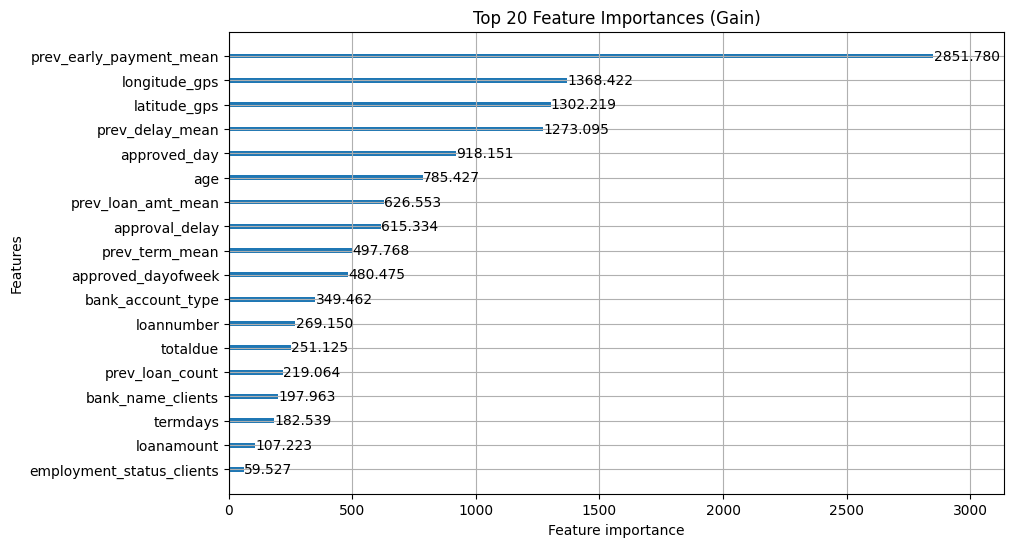

                    feature  importance
6             longitude_gps         397
16  prev_early_payment_mean         359
7              latitude_gps         357
15          prev_delay_mean         334
20             approved_day         247
17                      age         227
13       prev_loan_amt_mean         195
18           approval_delay         177
14           prev_term_mean         149
21       approved_dayofweek         134


In [ ]:
# feature importance
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd

lgbm_fe.fit(x_train, y_train)

# top-20 features
lgb.plot_importance(lgbm_fe, max_num_features=20, importance_type='gain', figsize=(10, 6))
plt.title("Top 20 Feature Importances (Gain)")
plt.show()

# full table
feat_imp = pd.DataFrame({
    'feature': x_train.columns,
    'importance': lgbm_fe.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

In [ ]:
# interaction fe -> further lower to 0.7873
# Combine education level and employment status - doesn't work
# x_train['edu_emp_status'] = x_train['level_of_education_clients'].astype(str) + '_' + x_train['employment_status_clients'].astype(str)

# Behaviour patterns
x_train['acctype_weekday'] = x_train['bank_account_type'].astype(str) + '_' + df_main['approveddate'].dt.dayofweek.astype(str)

# Regional risk patterns. - doesn't work
# x_train['geo_delay'] = (x_train['latitude_gps'] + x_train['longitude_gps']) * x_train['prev_delay_mean']


In [ ]:
print(x_train.columns)

Index(['loannumber', 'loanamount', 'totaldue', 'termdays', 'referredby',
       'bank_account_type', 'longitude_gps', 'latitude_gps',
       'bank_name_clients', 'bank_branch_clients', 'employment_status_clients',
       'level_of_education_clients', 'prev_loan_count', 'prev_loan_amt_mean',
       'prev_term_mean', 'prev_delay_mean', 'prev_early_payment_mean', 'age',
       'approval_delay', 'approved_month', 'approved_day',
       'approved_dayofweek', 'acctype_weekday'],
      dtype='object')


In [ ]:
for col in x_train.select_dtypes(include='object').columns:
    x_train[col] = x_train[col].astype('category')

# Instantiate unoptimized LGBM model
lgbm_interac = LGBMClassifier(random_state=42)

# Cross-validation using accuracy
scores = cross_val_score(lgbm_interac, x_train, y_train, cv=10, scoring='accuracy')

# interac score
print(f"Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")  # Accuracy: 0.7898 (+/- 0.0112)


[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001355 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.781989 -> initscore=1.277297
[LightGBM] [Info] Start training from score 1.277297
[LightGBM] [Info] Number of positive: 3074, number of negative: 857
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1546
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.781989 -> initscore=1.277297
[LightGBM] [I

[LightGBM] [Info] Number of positive: 3416, number of negative: 952
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1594
[LightGBM] [Info] Number of data points in the train set: 4368, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.782051 -> initscore=1.277661
[LightGBM] [Info] Start training from score 1.277661


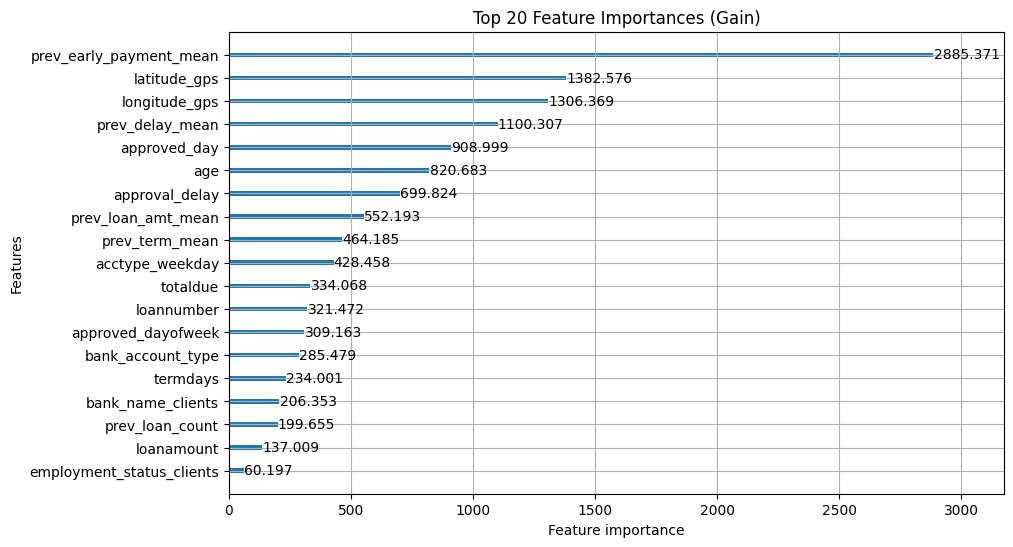

                    feature  importance
6             longitude_gps         395
7              latitude_gps         362
16  prev_early_payment_mean         361
15          prev_delay_mean         285
20             approved_day         241
17                      age         224
18           approval_delay         202
13       prev_loan_amt_mean         162
14           prev_term_mean         135
22          acctype_weekday         116


In [ ]:
# feature importance
lgbm_interac.fit(x_train, y_train)

# top-20 features
lgb.plot_importance(lgbm_interac, max_num_features=20, importance_type='gain', figsize=(10, 6))
plt.title("Top 20 Feature Importances (Gain)")
plt.show()

# full table
feat_imp = pd.DataFrame({
    'feature': x_train.columns,
    'importance': lgbm_interac.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

### Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define hyperparameter grid
param_dist = {
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 500],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0, 0.01, 0.1]
}

# 2. Initialize model
lgbm_model = LGBMClassifier(random_state=42, class_weight='balanced')

# 3. RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=param_dist,
    n_iter=100,  # number of random combinations to try
    cv=10,
    scoring='accuracy',
    verbose=1,
)

# 4. Fit
rand_search.fit(x_train, y_train)

# 5. Best parameters & score
print("Best Accuracy: ", rand_search.best_score_) #Best Accuracy:  0.7644065494289626
print("Best Params: ", rand_search.best_params_)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [ ]:
# import optuna

# # Step 1: Define objective function for Optuna
# def objective(trial):
#     params = {
#         'num_leaves': trial.suggest_int('num_leaves', 20, 128),
#         'max_depth': trial.suggest_int('max_depth', 3, 15),
#         'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
#         'random_state': 42,
#         'class_weight': 'balanced'
#     }

#     model = LGBMClassifier(**params)

#     # Use cross-validation to evaluate accuracy
#     scores = cross_val_score(model, x_train, y_train, cv=10, scoring='accuracy')

#     return scores.mean()

# # Step 2: Start Optuna optimization
# study = optuna.create_study(direction='maximize')  # maximize accuracy
# study.optimize(objective, n_trials=50, timeout=900)  # try 50 sets or stop after 15 mins

# print("Best Accuracy: ", study.best_value)
# print("Best Parameters: ", study.best_params)

[I 2025-07-25 22:02:37,423] A new study created in memory with name: no-name-b63b94fe-506b-4154-a9f6-40f5b5d37591


[LightGBM] [Info] Number of positive: 3080, number of negative: 858
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 3938, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

[I 2025-07-25 22:02:44,743] Trial 0 finished with value: 0.7102374011264014 and parameters: {'num_leaves': 79, 'max_depth': 7, 'learning_rate': 0.003360685414586934, 'n_estimators': 361, 'min_child_samples': 48, 'subsample': 0.8232560908064461, 'colsample_bytree': 0.8963394986835632, 'reg_alpha': 0.3782681475159746, 'reg_lambda': 0.5311311298043352}. Best is trial 0 with value: 0.7102374011264014.


[LightGBM] [Info] Number of positive: 3080, number of negative: 858
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 3938, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

[I 2025-07-25 22:02:49,313] Trial 1 finished with value: 0.7301166107645528 and parameters: {'num_leaves': 58, 'max_depth': 6, 'learning_rate': 0.06849692106595721, 'n_estimators': 240, 'min_child_samples': 15, 'subsample': 0.53232979584819, 'colsample_bytree': 0.5146012319046231, 'reg_alpha': 0.9451086876112518, 'reg_lambda': 0.5513795022579498}. Best is trial 1 with value: 0.7301166107645528.


...

[LightGBM] [Info] Number of positive: 3080, number of negative: 858
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 3938, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[I 2025-07-25 22:09:13,661] Trial 48 finished with value: 0.7596005349884539 and parameters: {'num_leaves': 108, 'max_depth': 13, 'learning_rate': 0.10921172437125076, 'n_estimators': 171, 'min_child_samples': 15, 'subsample': 0.5204275983783996, 'colsample_bytree': 0.7233840357170992, 'reg_alpha': 0.6034236762038402, 'reg_lambda': 0.34147044360076356}. Best is trial 35 with value: 0.76462806808564.


[LightGBM] [Info] Number of positive: 3080, number of negative: 858
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 3938, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

[I 2025-07-25 22:09:18,551] Trial 49 finished with value: 0.6766459776600524 and parameters: {'num_leaves': 92, 'max_depth': 5, 'learning_rate': 0.0010407015300037486, 'n_estimators': 281, 'min_child_samples': 21, 'subsample': 0.6573600486385263, 'colsample_bytree': 0.5283164038154557, 'reg_alpha': 0.30858761418105235, 'reg_lambda': 0.2894859164191122}. Best is trial 35 with value: 0.76462806808564.


Best Accuracy:  0.76462806808564
Best Parameters:  {'num_leaves': 121, 'max_depth': 11, 'learning_rate': 0.10377090759520945, 'n_estimators': 237, 'min_child_samples': 12, 'subsample': 0.5419490589789387, 'colsample_bytree': 0.5967478821495362, 'reg_alpha': 0.03863193808070092, 'reg_lambda': 0.5073710793298423}


## Catboost

In [ ]:
# features
drop_cols=['customerid', 'systemloanid', 'birthdate', 'creationdate', 'approveddate', 'good_bad_flag']
x_train = df_main.drop(columns = drop_cols)
x_train.info()
x_train.head()

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loannumber                  4368 non-null   int64  
 1   loanamount                  4368 non-null   float64
 2   totaldue                    4368 non-null   float64
 3   termdays                    4368 non-null   int64  
 4   referredby                  587 non-null    object 
 5   bank_account_type           3269 non-null   object 
 6   longitude_gps               3269 non-null   float64
 7   latitude_gps                3269 non-null   float64
 8   bank_name_clients           3269 non-null   object 
 9   bank_branch_clients         33 non-null     object 
 10  employment_status_clients   2776 non-null   object 
 11  level_of_education_clients  443 non-null    object 
 12  prev_loan_count             4359 non-null   float64
 13  prev_loan_amt_mean          4359 non-n

,loannumber,loanamount,totaldue,termdays,referredby,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,employment_status_clients,level_of_education_clients,prev_loan_count,prev_loan_amt_mean,prev_term_mean,prev_delay_mean,prev_early_payment_mean,age,approval_delay
0,12,30000.0,34500.0,30,NaN,Other,3.432010,6.433055,Diamond Bank,NaN,Permanent,Post-Graduate,11.0,18181.818182,30.0,29.363636,0.000000,53.0,0.041771
1,2,15000.0,17250.0,30,NaN,Savings,3.885298,7.320700,GT Bank,"DUGBE,IBADAN",Permanent,Graduate,NaN,NaN,NaN,NaN,NaN,40.0,0.041933
2,7,20000.0,22250.0,15,NaN,Other,11.139350,10.292041,EcoBank,NaN,Permanent,NaN,6.0,10000.000000,17.5,18.166667,-1.833333,41.0,0.041736
3,3,10000.0,11500.0,15,NaN,Savings,3.985770,7.491708,First Bank,NaN,Permanent,NaN,2.0,10000.000000,22.5,31.500000,-8.500000,48.0,0.041736
4,9,40000.0,44000.0,30,NaN,Other,7.457913,9.076574,GT Bank,NaN,Permanent,Primary,8.0,18750.000000,37.5,27.000000,2.125000,39.0,0.041736


### Feature Engineering

In [ ]:
# details of approval -> increased to 0.8
x_train['approved_month'] = df_main['approveddate'].dt.month
x_train['approved_day'] = df_main['approveddate'].dt.day
x_train['approved_dayofweek'] = df_main['approveddate'].dt.dayofweek

In [ ]:
# Missing Values, catboost cannot handle categorical missing value
for col in x_train.select_dtypes(include='object').columns:
    x_train[col] = x_train[col].fillna('missing')

# Missing Numerical Values - DOESNT WORK: accuracy goes down -> 0.7958
# cols_to_fill_0 = ['prev_loan_count', 'prev_loan_amt_mean', 'prev_term_mean', 'prev_delay_mean']
# x_train[cols_to_fill_0] = x_train[cols_to_fill_0].fillna(0)

# interaction on categorical feature
# edu x employment ->0.7967
# x_train["edu_employment"] = x_train["level_of_education_clients"].astype(str) + "_" + x_train["employment_status_clients"].astype(str)
# acc type x approvedate
# x_train["acctype_weekday"] = x_train["bank_account_type"].astype(str) + "_" + df_main["approveddate"].dt.dayofweek.astype(str)


x_train.info()
x_train.head(20)

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loannumber                  4368 non-null   int64  
 1   loanamount                  4368 non-null   float64
 2   totaldue                    4368 non-null   float64
 3   termdays                    4368 non-null   int64  
 4   referredby                  4368 non-null   object 
 5   bank_account_type           4368 non-null   object 
 6   longitude_gps               3269 non-null   float64
 7   latitude_gps                3269 non-null   float64
 8   bank_name_clients           4368 non-null   object 
 9   bank_branch_clients         4368 non-null   object 
 10  employment_status_clients   4368 non-null   object 
 11  level_of_education_clients  4368 non-null   object 
 12  prev_loan_count             4359 non-null   float64
 13  prev_loan_amt_mean          4359 non-n

,loannumber,loanamount,totaldue,termdays,referredby,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,...,prev_loan_count,prev_loan_amt_mean,prev_term_mean,prev_delay_mean,prev_early_payment_mean,age,approval_delay,approved_month,approved_day,approved_dayofweek
0,12,30000.0,34500.0,30,missing,Other,3.432010,6.433055,Diamond Bank,missing,...,11.0,18181.818182,30.000000,29.363636,0.000000,53.0,0.041771,7,25,1
1,2,15000.0,17250.0,30,missing,Savings,3.885298,7.320700,GT Bank,"DUGBE,IBADAN",...,NaN,NaN,NaN,NaN,NaN,40.0,0.041933,7,5,2
2,7,20000.0,22250.0,15,missing,Other,11.139350,10.292041,EcoBank,missing,...,6.0,10000.000000,17.500000,18.166667,-1.833333,41.0,0.041736,7,6,3
3,3,10000.0,11500.0,15,missing,Savings,3.985770,7.491708,First Bank,missing,...,2.0,10000.000000,22.500000,31.500000,-8.500000,48.0,0.041736,7,27,3
4,9,40000.0,44000.0,30,missing,Other,7.457913,9.076574,GT Bank,missing,...,8.0,18750.000000,37.500000,27.000000,2.125000,39.0,0.041736,7,3,0
5,8,30000.0,39000.0,60,missing,missing,NaN,NaN,missing,missing,...,7.0,14285.714286,30.000000,24.857143,4.428571,NaN,0.041736,7,19,2
6,3,10000.0,13000.0,30,missing,Savings,3.259444,6.557011,GT Bank,missing,...,2.0,10000.000000,22.500000,19.500000,1.500000,36.0,0.041725,7,10,0
7,10,30000.0,34500.0,30,missing,Savings,6.178056,5.425800,First Bank,missing,...,9.0,20000.000000,23.333333,22.111111,0.000000,38.0,0.041736,7,24,0
8,4,10000.0,11500.0,15,missing,Savings,3.396524,6.627943,GT Bank,missing,...,3.0,10000.000000,15.000000,17.666667,-2.333333,38.0,0.041759,7,26,2
9,2,10000.0,11500.0,15,missing,Savings,3.285872,6.582444,Access Bank,missing,...,1.0,10000.000000,15.000000,12.000000,2.000000,41.0,0.041748,7,17,0


### Models

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import cross_val_score


# Identify categorical columns
cat_features = x_train.select_dtypes(include='object').columns.tolist()

#  Instantiate CatBoost model (no tuning)
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    cat_features=cat_features
)

# Cross-validation
scores = cross_val_score(catboost_model, x_train, y_train, cv=10, scoring='accuracy', error_score='raise')

# Print results
print(f"CatBoost Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})") # Accuracy: 0.7969 (+/- 0.0099)

#Baseline Accurracy: 0.7965 (+/- 0.0089) - without further fe and tuning
#Fe-details on approveddate: Accuracy: 0.7992 (+/- 0.0124)
#log_transformation lower the performance; Accuracy: 0.7974 (+/- 0.0119)
#drop least important features lower the performance to 0.7979 (+/- 0.0123)

CatBoost Accuracy: 0.7992 (+/- 0.0124)


/tmp/ipython-input-2672074251.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=cat_feat_imp_df.head(20), palette='viridis')


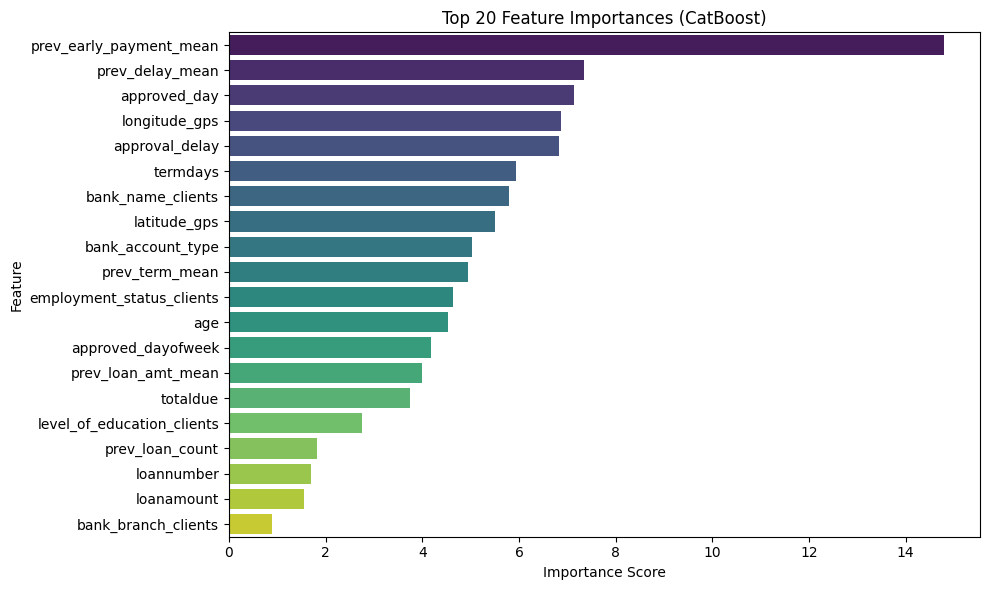

                feature  importance
0            loannumber    1.699736
1            loanamount    1.544143
9   bank_branch_clients    0.901403
4            referredby    0.000000
19       approved_month    0.000000


In [ ]:
# feature importance
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Identify categorical columns
cat_features = x_train.select_dtypes(include='object').columns.tolist()

# Train CatBoost model explicitly on full training set
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    cat_features=cat_features,
)
catboost_model.fit(x_train, y_train)

# Now get feature importances
cat_feat_importance = catboost_model.get_feature_importance()
cat_feat_names = x_train.columns

# Build dataframe
cat_feat_imp_df = pd.DataFrame({
    'feature': cat_feat_names,
    'importance': cat_feat_importance
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=cat_feat_imp_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (CatBoost)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# print(cat_feat_imp_df.head(5))
print(cat_feat_imp_df.tail(5))

### Skewness in top features

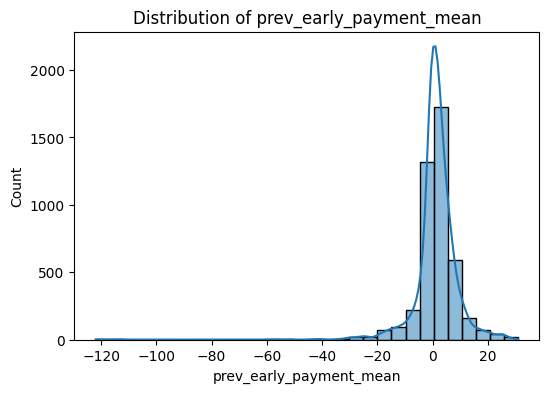

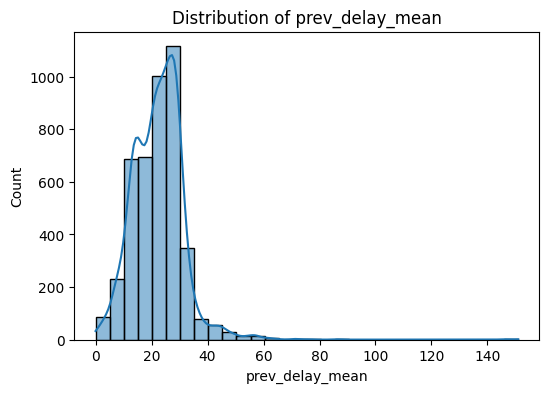

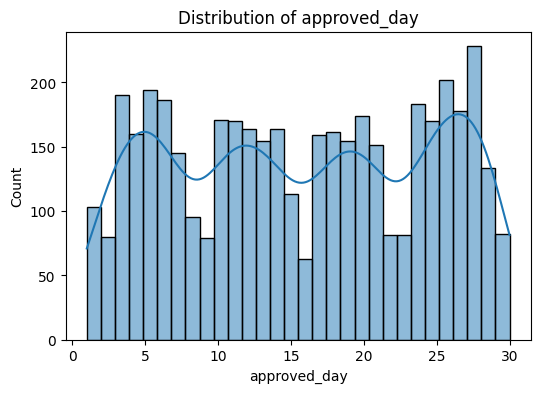

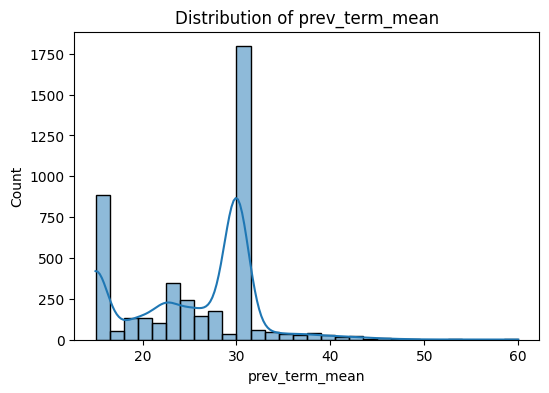

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['prev_early_payment_mean', 'prev_delay_mean', 'approved_day', 'prev_term_mean']:
    plt.figure(figsize=(6, 4))
    sns.histplot(x_train[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


### fe: log_transformation - doesnt work， lower the performance

In [ ]:
# log-transformation for top features
x_train['prev_delay_mean_log'] = np.log1p(x_train['prev_delay_mean'])
x_train['prev_early_payment_mean_log'] = np.log1p(x_train['prev_early_payment_mean'])
# x_train['approved_day_log'] = np.log1p(x_train['approved_day'])
x_train['prev_term_mean_log'] = np.log1p(x_train['prev_term_mean'])

x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loannumber                   4368 non-null   int64  
 1   loanamount                   4368 non-null   float64
 2   totaldue                     4368 non-null   float64
 3   termdays                     4368 non-null   int64  
 4   referredby                   4368 non-null   object 
 5   bank_account_type            4368 non-null   object 
 6   longitude_gps                3269 non-null   float64
 7   latitude_gps                 3269 non-null   float64
 8   bank_name_clients            4368 non-null   object 
 9   bank_branch_clients          4368 non-null   object 
 10  employment_status_clients    4368 non-null   object 
 11  level_of_education_clients   4368 non-null   object 
 12  prev_loan_count              4359 non-null   float64
 13  prev_loan_amt_mean     

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# try model
# Identify categorical columns
cat_features = x_train.select_dtypes(include='object').columns.tolist()

#  Instantiate CatBoost model (no tuning)
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    cat_features=cat_features
)

# Cross-validation
scores = cross_val_score(catboost_model, x_train, y_train, cv=10, scoring='accuracy', error_score='raise')

# Print results
print(f"CatBoost Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

CatBoost Accuracy: 0.7974 (+/- 0.0119)


### Drop least important features - doesn't work， performance decreases

In [ ]:
print(cat_feat_imp_df.tail(5))

                feature  importance
0            loannumber    1.699736
1            loanamount    1.544143
9   bank_branch_clients    0.901403
4            referredby    0.000000
19       approved_month    0.000000


In [ ]:
low_importance_features = ['bank_branch_clients']
x_train = x_train.drop(columns=low_importance_features)
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4368 entries, 0 to 4375
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loannumber                  4368 non-null   int64  
 1   loanamount                  4368 non-null   float64
 2   totaldue                    4368 non-null   float64
 3   termdays                    4368 non-null   int64  
 4   referredby                  4368 non-null   object 
 5   bank_account_type           4368 non-null   object 
 6   longitude_gps               3269 non-null   float64
 7   latitude_gps                3269 non-null   float64
 8   bank_name_clients           4368 non-null   object 
 9   employment_status_clients   4368 non-null   object 
 10  level_of_education_clients  4368 non-null   object 
 11  prev_loan_count             4359 non-null   float64
 12  prev_loan_amt_mean          4359 non-null   float64
 13  prev_term_mean              4359 non-n

In [ ]:
# try model
# Identify categorical columns
cat_features = x_train.select_dtypes(include='object').columns.tolist()

#  Instantiate CatBoost model (no tuning)
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    cat_features=cat_features
)

# Cross-validation
scores = cross_val_score(catboost_model, x_train, y_train, cv=10, scoring='accuracy', error_score='raise')

# Print results
print(f"CatBoost Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})") # Accuracy:  0.7972 (+/- 0.0102) goes down

CatBoost Accuracy: 0.7979 (+/- 0.0123)


### Hyperparameter Tuning

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

#  Define hyperparameter search space
param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.1],
    'iterations': [100, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0.1, 0.5, 1.0],
    'random_strength': [1, 5, 10],
    'border_count': [32, 64, 128],
    'rsm': [0.8, 1.0],  # feature sub-sampling
}

#  Instantiate CatBoostClassifier
catboost_model = CatBoostClassifier(
    cat_features=cat_features,
    verbose=0,
    random_state=42
)

#  Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=param_dist,
    n_iter=100,
    cv=10,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(x_train, y_train)

# Print results
print("Best Accuracy: ", random_search.best_score_) # Best Accuracy:  0.8005998992295258
print("Best Parameters: ", random_search.best_params_)
# Best Parameters:
# {'rsm': 1.0, 'random_strength': 1, 'learning_rate': 0.03, 'l2_leaf_reg': 9, 'iterations': 500, 'depth': 4, 'border_count': 32, 'bagging_temperature': 1.0}


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best Accuracy:  0.7994515357000399
Best Parameters:  {'rsm': 0.8, 'random_strength': 10, 'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 100, 'depth': 6, 'border_count': 64, 'bagging_temperature': 1.0}


#### optuna

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 17.0 MB/s eta 0:00:00


In [ ]:
# compute class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))


In [ ]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

# define objective function
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_categorical("border_count", [32, 64, 128]),
        "rsm": trial.suggest_float("rsm", 0.7, 1.0),
        "cat_features": cat_features,
        "verbose": 0,
        "random_state": 42,
        "class_weights": class_weights_dict  # handle class imbalance
    }

    model = CatBoostClassifier(**params)
    score = cross_val_score(model, x_train, y_train, cv=10, scoring='accuracy')
    return score.mean()

# tuning
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best Accuracy: ", study.best_value)
print("Best Hyperparameters: ", study.best_params)


[I 2025-08-04 19:39:04,997] A new study created in memory with name: no-name-b9370420-1d6e-4297-95f1-a656740b7380
[I 2025-08-04 19:39:45,534] Trial 0 finished with value: 0.7046669325887516 and parameters: {'iterations': 361, 'depth': 6, 'learning_rate': 0.013952035856595595, 'l2_leaf_reg': 9, 'random_strength': 9.994236483676099, 'bagging_temperature': 0.8382093958656583, 'border_count': 32, 'rsm': 0.9199075969090206}. Best is trial 0 with value: 0.7046669325887516.
[I 2025-08-04 19:41:58,025] Trial 1 finished with value: 0.7472508554993387 and parameters: {'iterations': 510, 'depth': 9, 'learning_rate': 0.04145187407624538, 'l2_leaf_reg': 8, 'random_strength': 7.72711814802796, 'bagging_temperature': 0.10425361961534496, 'border_count': 32, 'rsm': 0.8941028592660678}. Best is trial 1 with value: 0.7472508554993387.
[I 2025-08-04 19:42:50,090] Trial 2 finished with value: 0.7369517981231499 and parameters: {'iterations': 400, 'depth': 6, 'learning_rate': 0.0566397665030357, 'l2_leaf_r

Best Accuracy:  0.7747244557344698
Best Hyperparameters:  {'iterations': 819, 'depth': 10, 'learning_rate': 0.06647226935796456, 'l2_leaf_reg': 6, 'random_strength': 8.981062523695202, 'bagging_temperature': 0.14729932810875973, 'border_count': 32, 'rsm': 0.7469289615945726}


# Prediction

In [ ]:
# best model: catboost
from catboost import CatBoostClassifier, Pool
cat_features = x_train.select_dtypes(include='object').columns.tolist()
best_params = {
    'rsm': 0.8,
    'random_strength': 10,
    'learning_rate': 0.03,
    'l2_leaf_reg': 7,
    'iterations': 500,
    'depth': 8,
    'border_count': 64,
    'bagging_temperature': 0.1
}
final_catboost_model = CatBoostClassifier(
    **best_params,
    cat_features=cat_features,
    random_state=42,
    verbose=0
)
final_catboost_model.fit(x_train, y_train)

In [ ]:
# process test dataset
df_test_demo = pd.read_csv('MMA 869 Team Project/testdemographics.csv')
df_test_prev = pd.read_csv('MMA 869 Team Project/testprevloans.csv')
df_test_perf = pd.read_csv('MMA 869 Team Project/testperf.csv')

# 1. remove duplication
# testdemographics
duplicates_demo = df_test_demo[df_test_demo['customerid'].duplicated()]
print(f"testdemographics duplicated customerid: {duplicates_demo.shape[0]}")

# testperf
duplicates_perf = df_test_perf[df_test_perf['customerid'].duplicated()]
print(f"testperf duplicated customerid: {duplicates_perf.shape[0]}")
print("testdemographics:", duplicates_demo['customerid'].unique())
# remove duplication in demographic data
df_test_demo.drop_duplicates(subset='customerid', inplace=True)

# 2. aggregation
agg_test_prev = df_test_prev.groupby('customerid').agg(
    prev_loan_count=('systemloanid', 'nunique'),
    prev_loan_amt_mean=('loanamount', 'mean'),
    prev_term_mean=('termdays', 'mean'),
    prev_delay_mean=('firstrepaiddate', lambda d:
        ((pd.to_datetime(d) - pd.to_datetime(df_test_prev['creationdate'])).dt.days).mean())
).reset_index()

df_test_main = (df_test_perf
           .merge(df_test_demo, on='customerid', how='left')
           .merge(agg_test_prev, on='customerid', how='left'))
print(df_test_main.info())


testdemographics duplicated customerid: 3
testperf duplicated customerid: 0
testdemographics: ['8a8588b75438f49901544510041e0951' '8a858e885b68546c015b7238f22027ba'
 '8a858f2e5c699f3a015c6e10b65607c9']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customerid                  1450 non-null   object 
 1   systemloanid                1450 non-null   int64  
 2   loannumber                  1450 non-null   int64  
 3   approveddate                1450 non-null   object 
 4   creationdate                1450 non-null   object 
 5   loanamount                  1450 non-null   int64  
 6   totaldue                    1450 non-null   float64
 7   termdays                    1450 non-null   int64  
 8   referredby                  184 non-null    object 
 9   birthdate                   385 non-null    object 
 10  ba

In [ ]:
# 3. date manipulation, since most model cannot handle date values
df_test_main['birthdate'] = pd.to_datetime(df_test_main['birthdate'], errors='coerce')
df_test_main['creationdate'] = pd.to_datetime(df_test_main['creationdate'], errors='coerce')
df_test_main['approveddate'] = pd.to_datetime(df_test_main['approveddate'], errors='coerce')


df_test_main['age'] = 2025 - df_test_main['birthdate'].dt.year
df_test_main['approval_delay'] = (df_test_main['approveddate'] - df_test_main['creationdate']).dt.total_seconds() / 86400
df_test_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customerid                  1450 non-null   object        
 1   systemloanid                1450 non-null   int64         
 2   loannumber                  1450 non-null   int64         
 3   approveddate                597 non-null    datetime64[ns]
 4   creationdate                591 non-null    datetime64[ns]
 5   loanamount                  1450 non-null   int64         
 6   totaldue                    1450 non-null   float64       
 7   termdays                    1450 non-null   int64         
 8   referredby                  184 non-null    object        
 9   birthdate                   385 non-null    datetime64[ns]
 10  bank_account_type           385 non-null    object        
 11  longitude_gps               385 non-null    float64     

/tmp/ipython-input-410446913.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test_main['creationdate'] = pd.to_datetime(df_test_main['creationdate'], errors='coerce')
/tmp/ipython-input-410446913.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test_main['approveddate'] = pd.to_datetime(df_test_main['approveddate'], errors='coerce')


In [ ]:
# 4. features
# features
drop_cols=['customerid', 'systemloanid', 'birthdate', 'creationdate', 'approveddate']
x_test = df_test_main.drop(columns = drop_cols)

# details of approval
x_test['approved_month'] = df_test_main['approveddate'].dt.month
x_test['approved_day'] = df_test_main['approveddate'].dt.day
x_test['approved_dayofweek'] = df_test_main['approveddate'].dt.dayofweek

# Missing Values, catboost cannot handle categorical missing value
for col in x_test.select_dtypes(include='object').columns:
    x_test[col] = x_test[col].fillna('missing')

x_test.info()
x_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loannumber                  1450 non-null   int64  
 1   loanamount                  1450 non-null   int64  
 2   totaldue                    1450 non-null   float64
 3   termdays                    1450 non-null   int64  
 4   referredby                  1450 non-null   object 
 5   bank_account_type           1450 non-null   object 
 6   longitude_gps               385 non-null    float64
 7   latitude_gps                385 non-null    float64
 8   bank_name_clients           1450 non-null   object 
 9   bank_branch_clients         1450 non-null   object 
 10  employment_status_clients   1450 non-null   object 
 11  level_of_education_clients  1450 non-null   object 
 12  prev_loan_count             1442 non-null   float64
 13  prev_loan_amt_mean          1442 

,loannumber,loanamount,totaldue,termdays,referredby,bank_account_type,longitude_gps,latitude_gps,bank_name_clients,bank_branch_clients,...,level_of_education_clients,prev_loan_count,prev_loan_amt_mean,prev_term_mean,prev_delay_mean,age,approval_delay,approved_month,approved_day,approved_dayofweek
0,4,10000,12250.0,30,missing,missing,NaN,NaN,missing,missing,...,missing,3.0,8666.666667,25.000000,27.666667,NaN,NaN,NaN,NaN,NaN
1,10,40000,44000.0,30,missing,missing,NaN,NaN,missing,missing,...,missing,9.0,23888.888889,31.666667,24.000000,NaN,NaN,NaN,NaN,NaN
2,6,20000,24500.0,30,missing,Savings,3.227945,6.586668,UBA,missing,...,missing,5.0,13000.000000,27.000000,31.000000,44.0,0.004861,8.0,1.0,4.0
3,8,30000,34500.0,30,missing,missing,NaN,NaN,missing,missing,...,missing,7.0,17142.857143,17.142857,13.428571,NaN,0.003472,8.0,1.0,4.0
4,4,20000,24500.0,30,missing,Savings,5.248368,13.059864,UBA,missing,...,missing,3.0,10000.000000,25.000000,21.666667,50.0,0.004167,8.0,1.0,4.0


In [ ]:
#prediction
y_pred = final_catboost_model.predict(x_test)
customer_ids = df_test_main['customerid']
submission = pd.DataFrame({
    'customerid': customer_ids,
    'prediction': y_pred
})
submission.info()
submission.head()
submission.to_csv('submission.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  1450 non-null   object
 1   prediction  1450 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.8+ KB
